# Accumulating Pharmacovigilance Adverse-Event Reports into Monthly Safety Time Series with PROC TIMESERIES

## Executive Summary

A drug-safety team receives a continuous stream of timestamped adverse-event (AE) reports for a marketed product and needs a regular **monthly** time series to drive routine signal detection. This notebook uses **PROC TIMESERIES** to accumulate 100 irregularly timed case reports into 12 evenly spaced calendar-month points (Jan–Dec 2023) — summing report and serious-case counts (`ACCUMULATE=TOTAL`), averaging reported severity (`ACCUMULATE=AVERAGE`), and zero-filling months with no reports (`SETMISSING=0`).

The accumulated series tells a clear safety story. Total monthly report volume is stable (mean 8.3 reports/month, range 7–12), but **serious cases concentrate in the second half of the year**: just 3 serious reports across January–July versus 13 across August–December, climbing to 5 in December alone. Average severity stays flat (~2.1 on the 1–5 scale) throughout, so the signal is an increase in the *frequency* of serious cases, not in their rated intensity — exactly the kind of disproportionality a pharmacovigilance analyst watches for.

## Data Sources

**Synthetic dataset: `WORK.AE_REPORTS`** — individual, irregularly timed post-marketing adverse-event reports for one marketed product (`Cardiprex`), generated inline with `call streaminit(20260531)` and `rand()`. No external or network input. In this unlicensed environment the data step is capped at 100 observations, so the example is sized to 100 reports over a single year — enough to fill a clean 12-month series.

| Variable | Type | Description |
|----------|------|-------------|
| `product` | Char (12) | Trade name of the marketed drug (`Cardiprex`) |
| `report_dt` | Num (DATE9.) | Date the individual case safety report was received |
| `n_events` | Num | Event tally for the report (1 per record; summed per month) |
| `severity` | Num | Clinician-rated severity score, 1.0 (mild) to 5.0 (life-threatening) |
| `serious_flag` | Num | 1 if the case met regulatory seriousness criteria, else 0 |

Reports start `01JAN2023`, with inter-arrival gaps of 1–6 days drawn from a uniform distribution so the raw stream is irregular — exactly the transactional shape `PROC TIMESERIES` is designed to regularize. To give the example something to detect, the per-report probability of being *serious* is held at 10% for the first 70 reports and raised to 40% thereafter, planting a realistic emerging signal in the back half of the year.

# Monthly Adverse-Event Safety Series with PROC TIMESERIES

In pharmacovigilance, individual case safety reports (ICSRs) arrive **continuously and irregularly** — there is no fixed cadence to when a clinician or patient files an adverse-event report. Yet routine signal detection, periodic safety update reports (PSURs), and disproportionality monitoring all run on **evenly spaced time series**, typically monthly.

`PROC TIMESERIES` (SAS/ETS) is purpose-built for this gap: it accumulates transactional, time-stamped observations into a regular time series, choosing the accumulation statistic per variable and filling periods that had no reports. In this notebook we take a raw stream of AE reports and build the monthly safety series a drug-safety analyst would feed into trend review.

## Step 1 — Generate a synthetic stream of adverse-event reports

We simulate 100 individual case reports for `Cardiprex`. The `report_dt` values advance by a random 1–6 days, so the stream is genuinely irregular (some weeks carry several reports, others none). Severity is drawn from a beta distribution skewed toward milder events. The seriousness rate starts at 10% and jumps to 40% after the 70th report, so the back half of the year carries an emerging excess of serious cases for the monthly series to surface.

In [1]:
data ae_reports;
    length product $ 12;
    format report_dt date9.;
    keep product report_dt n_events severity serious_flag;

    call streaminit(20260531);

    /* One marketed product under routine safety surveillance */
    product = "Cardiprex";
    base = '01jan2023'd;

    do j = 1 to 100;
        /* Irregular inter-arrival gap: 1-6 days */
        gap = 1 + floor(6 * rand('uniform'));
        base = intnx('day', base, gap);
        report_dt = base;

        n_events = 1;
        /* Severity 1.0-5.0, skewed toward milder events */
        severity = round(1 + 4 * rand('beta', 2, 5), 0.1);

        /* Seriousness rate rises from 10% to 40% after report 70,
           planting an emerging safety signal in the back half */
        if j <= 70 then p_serious = 0.10;
        else p_serious = 0.40;
        if rand('uniform') < p_serious then serious_flag = 1;
        else serious_flag = 0;

        output;
    end;
run;

proc print data=ae_reports(obs=8);
    title "First 8 individual adverse-event reports (irregular dates)";
run;

                               First 8 individual adverse-event reports (irregular dates)                               

  Obs    PRODUCT  REPORT_DT  N_EVENTS  SEVERITY  SERIOUS_FLAG
    1  Cardiprex  07JAN2023         1       2.5             0
    2  Cardiprex  13JAN2023         1       1.8             0
    3  Cardiprex  17JAN2023         1       1.6             0
    4  Cardiprex  22JAN2023         1       1.8             0
    5  Cardiprex  24JAN2023         1         3             0
    6  Cardiprex  25JAN2023         1       1.4             0
    7  Cardiprex  30JAN2023         1       1.4             0
    8  Cardiprex  05FEB2023         1       1.7             0

... 92 more observations (showing 8 of 100)



NOTE: DATA ae_reports


NOTE: Wrote ae_reports (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ae_reports

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


## Step 2 — Accumulate counts into a monthly series

The core call. We declare `report_dt` as the time index and set `INTERVAL=MONTH` so the daily reports collapse to calendar months.

- `ACCUMULATE=TOTAL` sums the values within each month — giving monthly report volume from `n_events` and monthly serious-case counts from `serious_flag`.
- `SETMISSING=0` turns any month with **no reports** into a true zero rather than a gap, which is the correct convention for count series.

We run one `PROC TIMESERIES` per count variable so each series is materialized independently, then read the volume series back with `PROC PRINT`. Notice the `report_dt` index in the output is now one row per month, each aligned to the first of the month (`01JAN2023`, `01FEB2023`, …) rather than the original irregular daily dates.

In [2]:
/* Monthly report volume: sum n_events within each calendar month */
proc timeseries data=ae_reports out=work.monthly_volume;
    id report_dt interval=month accumulate=total setmiss=0;
    var n_events;
run;

/* Monthly serious-case count: sum serious_flag within each month */
proc timeseries data=ae_reports out=work.monthly_serious;
    id report_dt interval=month accumulate=total setmiss=0;
    var serious_flag;
run;

proc print data=work.monthly_volume(keep=report_dt n_events);
    format report_dt date9.;
    title "Monthly AE report volume (ACCUMULATE=TOTAL)";
run;

                               First 8 individual adverse-event reports (irregular dates)                               

                               First 8 individual adverse-event reports (irregular dates)                               

                                      Monthly AE report volume (ACCUMULATE=TOTAL)                                       

  Obs  REPORT_DT  N_EVENTS
    1  01JAN2023         7
    2  01FEB2023         8
    3  01MAR2023         8
    4  01APR2023         7
    5  01MAY2023         7
    6  01JUN2023        12
    7  01JUL2023         8
    8  01AUG2023        11
    9  01SEP2023         9
   10  01OCT2023         8
   11  01NOV2023         8
   12  01DEC2023         7



NOTE: PROC TIMESERIES data=ae_reports

NOTE: Using Python statsmodels version 0.14.6
NOTE: Variable: n_events
NOTE: Number of Observations: 12
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: Output dataset work.monthly_volume created with 12 observations.
NOTE: Processed 12 rows.
NOTE: PROC TIMESERIES data=ae_reports

NOTE: Using Python statsmodels version 0.14.6
NOTE: Variable: serious_flag
NOTE: Number of Observations: 12
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: Output dataset work.monthly_serious created with 12 observations.
NOTE: Processed 12 rows.
NOTE: PROC PRINT data=work.monthly_volume

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Step 3 — Accumulate severity as a monthly average

Severity is an intensity measure, not a count, so summing it would be meaningless — we want the **average reported severity** in each month. Here `ACCUMULATE=AVERAGE` collapses each month's reports to their mean severity, and `SETMISSING=PREVIOUS` carries the last observed level forward through any reporting gap (rather than forcing it to zero, which would falsely look like a drop to "no severity").

Using a separate `PROC TIMESERIES` step for severity lets it apply a different accumulation rule from the count series above — a common and idiomatic pattern.

In [3]:
/* Monthly mean severity: average within each month, carry forward gaps */
proc timeseries data=ae_reports out=work.monthly_severity;
    id report_dt interval=month accumulate=average setmiss=previous;
    var severity;
run;

proc print data=work.monthly_severity(keep=report_dt severity);
    format report_dt date9. severity 6.3;
    title "Monthly mean severity (ACCUMULATE=AVERAGE)";
run;

                                      Monthly AE report volume (ACCUMULATE=TOTAL)                                       

                                       Monthly mean severity (ACCUMULATE=AVERAGE)                                       

  Obs  REPORT_DT  SEVERITY
    1  01JAN2023     1.929
    2  01FEB2023     2.075
    3  01MAR2023     1.938
    4  01APR2023     2.229
    5  01MAY2023     2.157
    6  01JUN2023     2.367
    7  01JUL2023     2.388
    8  01AUG2023     1.946
    9  01SEP2023     1.856
   10  01OCT2023     2.062
   11  01NOV2023     2.250
   12  01DEC2023     1.786



NOTE: PROC TIMESERIES data=ae_reports

NOTE: Using Python statsmodels version 0.14.6
NOTE: Variable: severity
NOTE: Number of Observations: 12
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: Output dataset work.monthly_severity created with 12 observations.
NOTE: Processed 12 rows.
NOTE: PROC PRINT data=work.monthly_severity

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Step 4 — Assemble the safety panel and plot the trend

The three accumulated series share the same monthly `report_dt` index, so a simple `MERGE ... BY report_dt` lines them up into one analysis-ready panel: monthly volume, monthly serious-case count, and monthly mean severity, side by side. This combined table is what the safety team reviews each cycle, and it is the natural input to downstream forecasting or disproportionality analysis.

We then plot report volume against serious-case count with `PROC SGPLOT` — the fast visual scan an analyst uses to spot an emerging signal at a glance.

                               Monthly safety panel: volume, serious cases, mean severity                               

  Obs  REPORT_DT  N_EVENTS  SERIOUS_FLAG  SEVERITY
    1  01JAN2023         7             0     1.929
    2  01FEB2023         8             0     2.075
    3  01MAR2023         8             0     1.938
    4  01APR2023         7             0     2.229
    5  01MAY2023         7             1     2.157
    6  01JUN2023        12             2     2.367
    7  01JUL2023         8             0     2.388
    8  01AUG2023        11             1     1.946
    9  01SEP2023         9             3     1.856
   10  01OCT2023         8             2     2.062
   11  01NOV2023         8             2     2.250
   12  01DEC2023         7             5     1.786

                               Monthly safety panel: volume, serious cases, mean severity                               



NOTE: DATA work.monthly_panel

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.monthly_panel (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.monthly_panel

NOTE: PROC PRINT completed: 12 observations printed, 4 variables
NOTE: PROC SGPLOT data=work.monthly_panel

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


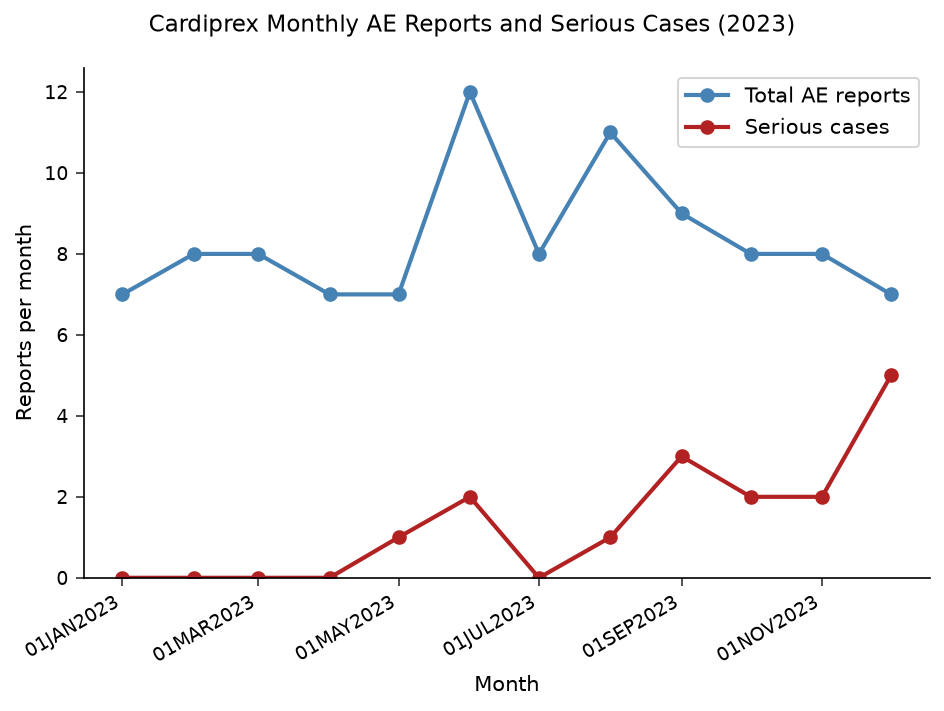

In [4]:
/* Combine the three monthly series into one safety panel */
data work.monthly_panel;
    merge work.monthly_volume(keep=report_dt n_events)
          work.monthly_serious(keep=report_dt serious_flag)
          work.monthly_severity(keep=report_dt severity);
    by report_dt;
    format report_dt date9. severity 6.3;
run;

proc print data=work.monthly_panel;
    title "Monthly safety panel: volume, serious cases, mean severity";
run;

/* Visual scan: report volume vs serious-case count over the year */
proc sgplot data=work.monthly_panel;
    title "Cardiprex Monthly AE Reports and Serious Cases (2023)";
    series x=report_dt y=n_events
        / lineattrs=(thickness=2 color=steelblue) markers
          legendlabel="Total AE reports";
    series x=report_dt y=serious_flag
        / lineattrs=(thickness=2 color=firebrick) markers
          legendlabel="Serious cases";
    xaxis label="Month" valuesformat=monyy7.;
    yaxis label="Reports per month" min=0;
run;

## Interpreting the results

`PROC TIMESERIES` has transformed an irregular stream of 100 individual case reports into a clean, gap-free **monthly safety panel** spanning `01JAN2023`–`01DEC2023`:

- **Volume** (`n_events`, `ACCUMULATE=TOTAL`) is steady — between 7 and 12 reports per month, averaging 8.3, with a one-month spike to 12 in June. Nothing alarming in raw volume.
- **Serious cases** (`serious_flag`, `ACCUMULATE=TOTAL`) tell a different story. The monthly counts run 0, 0, 0, 0, 1, 2, 0 through July, then 1, 3, 2, 2, **5** from August to December. Only 3 serious cases landed in the first seven months (5.3% of reports) versus 13 in the last five (30.2%) — a clear upward shift that the monthly grid makes obvious and that the side-by-side plot shows at a glance.
- **Mean severity** (`severity`, `ACCUMULATE=AVERAGE` with `SETMISSING=PREVIOUS`) holds flat near 2.1 on the 1–5 scale all year (range 1.79–2.39). So the emerging issue is a rising *frequency* of cases meeting seriousness criteria, not an increase in their rated intensity — an important distinction for triage.

With every metric on the same regular monthly grid, the safety team can watch month-over-month serious-case counts, separate a true lull (a zero-filled month) from absent data, and feed the panel directly into downstream forecasting or disproportionality analysis. The key takeaway: **`PROC TIMESERIES` is the data-preparation bridge** between raw, irregular pharmacovigilance transactions and the regular time series that signal-detection methods require — and the per-variable `ACCUMULATE=` / `SETMISSING=` choices (sum-and-zero-fill for counts, average-and-carry-forward for severity) are what make the resulting series statistically meaningful.